# Universidad Nacional Autónoma de México
# Diplomado en Técnicas Estadísticas y Mineria de Datos

# Módulo II: Probabilidad y Modelos Estadísticos.
## Notebook 2: Variables Aleatorias y Teoremas Límite

## Nombre: José Manuel Gómez Vaca

---

## 1. Variables Aleatorias Discretas

Una variable aleatoria discreta $X$ es una función definida sobre un espacio de probabilidad $(\Omega,\mathcal{F},P)$,

$X:\Omega \rightarrow \mathbb{R}$

tal que el conjunto de valores posibles de la variable,

$R_X=X(\Omega)$,

es finito o numerablemente infinito.

### Caracteristicas de una Variable Aleatoria Discreta:

- **Función de Masa de Probabilidad (FMP / PMF):**

La distribución de probabilidad de $X$ se describe mediante la función:

$p_X(x)=P(X=x)$

donde $x\in R_X$. Esta función cumple las condiciones:

$p_X(x)\geq0,\quad \forall x\in R_X$

y

$\sum_{x\in R_X}p_X(x)=1$.

- **Función de Distribución Acumulada (FDA / CDF):**

La función de distribución acumulada representa la probabilidad de que la variable aleatoria tome un valor menor o igual que $x$:

$F_X(x)=P(X\leq x)$

Para una variable aleatoria discreta:

$F_X(x)=\sum_{x\leq x}p_X(x)$

- **Momentos de una Variable Aleatoria:**

La esperanza o valor esperado de $X$ se define como:

$E(X)=\sum_{x\in R_X}x\,p_X(x)$

La varianza mide la dispersión de los valores de la variable respecto a su esperanza:

$Var(X)=E((X-E(X))^2)$

equivalentemente:

$Var(X)=E(X^2)-(E(X))^2$

---

## 2. Distribuciones Discretas Clásicas

### 2.1 Distribución Uniforme Discreta $U(a, b)$

#### Caracteristicas
- **Rango:** $R_X = \{a, a+1, a+2, \dots, b\}$
- **FMP:** $p_X(x) = \frac{1}{b - a + 1}, \quad x \in R_X$
- **FDA:** $F_X(x) = \begin{cases} 0 & x < a \\ \frac{\lfloor x \rfloor - a + 1}{b - a + 1} & a \leq x \leq b \\ 1 & x > b \end{cases}$
- **Esperanza:** $E[X] = \frac{a + b}{2}$
- **Varianza:** $Var(X) = \frac{(b - a + 1)^2 - 1}{12}$

#### Ejercicio
Un canal de transmisión digital selecciona un entero al azar entre $a = 1$ y $b = 10$ para asignar el identificador de paquete. 
1. Encuentre la FDA evaluada en $x = 6.5$.
2. Calcule la probabilidad $P(X \geq 7)$.

**Desarrollo Analítico:**
- Para $x = 6.5$, $\lfloor 6.5 \rfloor = 6$. Por lo tanto, $F_X(6.5) = P(X \leq 6) = \frac{6 - 1 + 1}{10} = \frac{6}{10} = 0.60$.
- $P(X \geq 7) = 1 - P(X \leq 6) = 1 - F_X(6) = 1 - 0.60 = 0.40$.

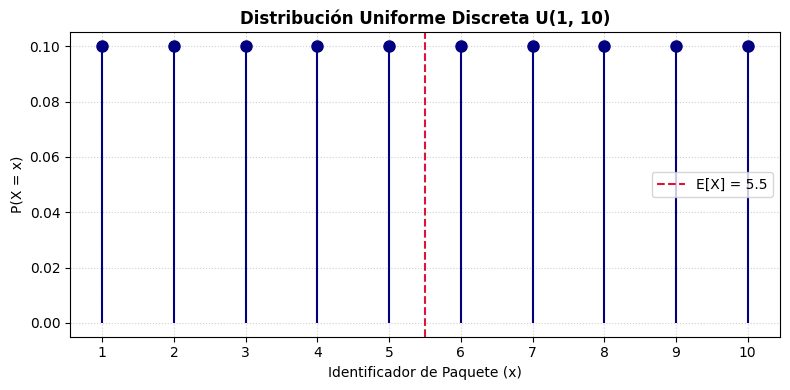

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

a, b = 1, 10
x_unif = np.arange(a, b + 1)
pmf_unif = stats.randint.pmf(x_unif, a, b + 1)

plt.figure(figsize=(8, 4))
marxerline, stemlines, _ = plt.stem(x_unif, pmf_unif, basefmt=" ")
plt.setp(marxerline, color='navy', markersize=8)
plt.setp(stemlines, color='navy', linewidth=1.5)
plt.axvline(x=5.5, color='crimson', linestyle='--', label='E[X] = 5.5')
plt.title("Distribución Uniforme Discreta U(1, 10)", fontsize=12, fontweight='bold')
plt.xlabel("Identificador de Paquete (x)")
plt.ylabel("P(X = x)")
plt.xticks(x_unif)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 2.2 Distribución Uniforme Discreta $U(a, b)$

### Problema (Ross):
Un dado perfecto de 6 caras se lanza una vez. Sea $X$ el resultado obtenido en la cara superior. Determine la probabilidad acumulada de obtener un valor menor o igual a cada posible resultado.

### Formalización Matemática:
- **Parámetros:** $a = 1, b = 6$
- **Rango:** $R_X = \{1, 2, 3, 4, 5, 6\}$
- **FMP:** $p_X(k) = \frac{1}{6}, \quad k \in R_X$
- **FDA:** $F_X(x) = \begin{cases} 0 & x < 1 \\ \frac{\lfloor x \rfloor}{6} & 1 \leq x \leq 6 \\ 1 & x > 6 \end{cases}$

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\3623895431.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.step(rango_unif, fda_unif, where='post', color='navy', lw=2.5, label='$F_X(x) = P(X \leq x)$')
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\3623895431.py:14: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")


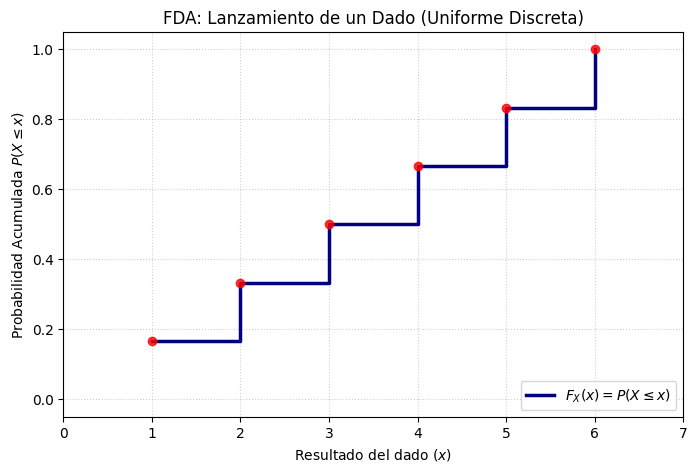

In [3]:
#Ahora un problema mostrando la acumulada de probabilidad para la distribución uniforme
#parametros
a, b = 1, 6
x_vals = np.linspace(0, 7, 1000)
rango_unif = np.arange(a, b + 1)
fda_unif = stats.randint.cdf(rango_unif, a, b + 1)

plt.figure(figsize=(8, 5))
plt.step(rango_unif, fda_unif, where='post', color='navy', lw=2.5, label='$F_X(x) = P(X \leq x)$')
plt.plot(rango_unif, fda_unif, 'ro', alpha=0.8)

plt.title("FDA: Lanzamiento de un Dado (Uniforme Discreta)")
plt.xlabel("Resultado del dado ($x$)")
plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")
plt.xticks(np.arange(0, 8))
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc='lower right')
plt.show()

### 2.3 Distribución Bernoulli $Ber(p)$

#### Caracteristicas
- **Rango:** $R_X = \{0, 1\}$
- **FMP:** $p_X(x) = p^x (1-p)^{1-x}, \quad x \in \{0, 1\}$
- **FDA:** $F_X(x) = \begin{cases} 0 & x < 0 \\ 1 - p & 0 \leq x < 1 \\ 1 & x \geq 1 \end{cases}$
- **Esperanza:** $E[X] = p$
- **Varianza:** $Var(X) = p(1-p)$

#### Ejercicio Práctico Resuelto
Un componente electrónico en un circuito se somete a una prueba de sobrecarga. El componente funciona con éxito ($X = 1$) con probabilidad $p = 0.85$ y falla ($X = 0$) en caso contrario.
1. Calcule la FDA para todo $x \in \mathbb{R}$.
2. Determine la varianza del ensayo.

**Desarrollo Analítico:**
- $F_X(x) = 0$ para $x < 0$; $F_X(x) = 1 - 0.85 = 0.15$ para $0 \leq x < 1$; $F_X(x) = 1.0$ para $x \geq 1$.
- $Var(X) = p(1-p) = (0.85)(0.15) = 0.1275$.

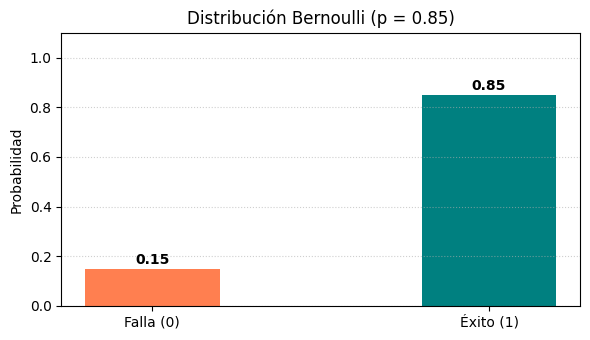

In [42]:
p_bern = 0.85
x_bern = [0, 1]
pmf_bern = stats.bernoulli.pmf(x_bern, p_bern)

plt.figure(figsize=(6, 3.5))
bars = plt.bar(["Falla (0)", "Éxito (1)"], pmf_bern, color=['coral', 'teal'], width=0.4)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontweight='bold')
plt.ylim(0, 1.1)
plt.title(f"Distribución Bernoulli (p = {p_bern})")
plt.ylabel("Probabilidad")
plt.grid(axis='y', linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### 2.4 Problema (tomado de Bertsekas)

En una línea de ensamble automatizada se inspecciona un componente electrónico. La probabilidad de que la pieza presente un defecto es $p=0.3$. Definimos la variable aleatoria:

$X=
\begin{cases}
1, & \text{si la pieza presenta defecto}\\
0, & \text{si la pieza está conforme}
\end{cases}$

Entonces:

$X\sim Ber (0.3)$

### Formalización Matemática:

- **Parámetro:** $p=0.3$

- **Rango:** $R_X=\{0,1\}$

- **Función de Masa de Probabilidad (FMP):**

$p_X(k)=p^x(1-p)^{1-x}$, para $x\in\{0,1\}$

Sustituyendo $p=0.3$:

$p_X(k)=(0.3)^x(1-0.7)^{1-x}$

- **Función de Distribución Acumulada (FDA):**

$F_X(x)=
\begin{cases}
0, & x<0\\
0.7, & 0\leq x<1\\
1, & x\geq1
\end{cases}$

<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\1127565945.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")


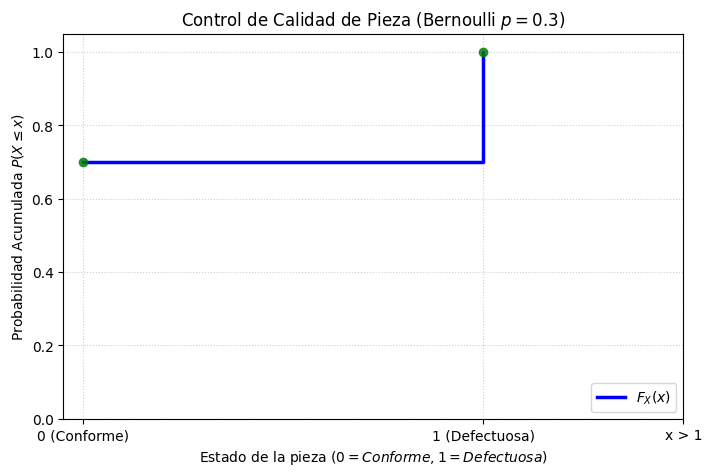

In [14]:
# Definimos los parametros de la distribución acumulada Bernoulli
p_bern = 0.3
rango_bern = np.array([0, 1])
fda_bern = stats.bernoulli.cdf(rango_bern, p_bern)

plt.figure(figsize=(8, 5))
plt.step(rango_bern, fda_bern, where='post', color='blue', lw=2.5, label='$F_X(x)$')
plt.plot(rango_bern, fda_bern, 'go', alpha=0.8)

plt.title("Control de Calidad de Pieza (Bernoulli $p=0.3$)")
plt.xlabel("Estado de la pieza ($0 = Conforme, 1 = Defectuosa$)")
plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")
plt.xticks([0, 1, 1.5], ['0 (Conforme)', '1 (Defectuosa)', 'x > 1'])
plt.ylim(0, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc='lower right')
plt.show()

### 2.5 Distribución Binomial $Bin(n, p)$

#### Marco Teórico
- **Soporte:** $R_X = \{0, 1, 2, \dots, n\}$
- **FMP:** $p_X(x) = \binom{n}{x} p^x (1-p)^{n-x}, \quad x \in R_X$
- **FDA:** $F_X(x) = \sum_{k=0}^{\lfloor x \rfloor} \binom{n}{k} p^k (1-p)^{n-k}, \quad 0 \leq x \leq n$
- **Esperanza:** $E[X] = np$
- **Varianza:** $Var(X) = np(1-p)$

#### Ejercicio
Un examen de opción múltiple consta de $n = 10$ preguntas independientes, cada una con 4 opciones (probabilidad de acertar al azar $p = 0.25$). Un estudiante responde totalmente al azar. Sean $X$ los aciertos.
1. Encuentre la probabilidad de aprobar el examen con al menos 6 aciertos ($P(X \geq 6)$).
2. Exprese esta probabilidad utilizando la FDA $F_X(x)$.

**Desarrollo Analítico:**
- Usando la propiedad del complemento: $P(X \geq 6) = 1 - P(X \leq 5) = 1 - F_X(5)$.
- $F_X(5) = \sum_{k=0}^5 \binom{10}{k} (0.25)^k (0.75)^{10-k} \approx 0.9803$.
- $P(X \geq 6) = 1 - 0.9803 = 0.0197$ ($1.97\%$).

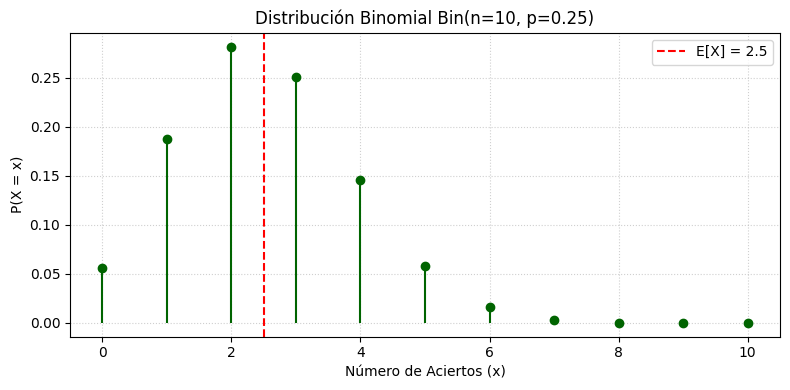

In [43]:
n_bin, p_bin = 10, 0.25
x_bin = np.arange(0, n_bin + 1)
pmf_bin = stats.binom.pmf(x_bin, n_bin, p_bin)

plt.figure(figsize=(8, 4))
plt.stem(x_bin, pmf_bin, basefmt=" ", linefmt='darkgreen', markerfmt='DarkGreen')
plt.axvline(x=n_bin*p_bin, color='red', linestyle='--', label=f'E[X] = {n_bin*p_bin}')
plt.title(f"Distribución Binomial Bin(n={n_bin}, p={p_bin})")
plt.xlabel("Número de Aciertos (x)")
plt.ylabel("P(X = x)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 2.6 Distribución Binomial $Bin(n, p)$

### Problema (Ross):
Un sistema de pruebas analiza un lote de $n = 10$ componentes producidos de forma independiente. Se sabe por histórico que cada componente tiene una probabilidad de fallar $p = 0.2$. Sea $X$ el número total de componentes defectuosos en el lote.

### Formalización Matemática:
- **Parámetros:** $n = 10, p = 0.2$
- **Rango:** $R_X = \{0, 1, 2, \dots, 10\}$
- **FMP:** $p_X(x) = \binom{10}{x} (0.2)^x (0.8)^{10-x}, \quad x \in R_X$
- **FDA:** $F_X(x) = \sum_{k=0}^{\lfloor x \rfloor} \binom{10}{k} (0.2)^k (0.8)^{10-k}$

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\3065367043.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.step(rango_bin, fda_bin, where='post', color='purple', lw=2.5, label='$F_X(x) = P(X \leq x)$')
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\3065367043.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")


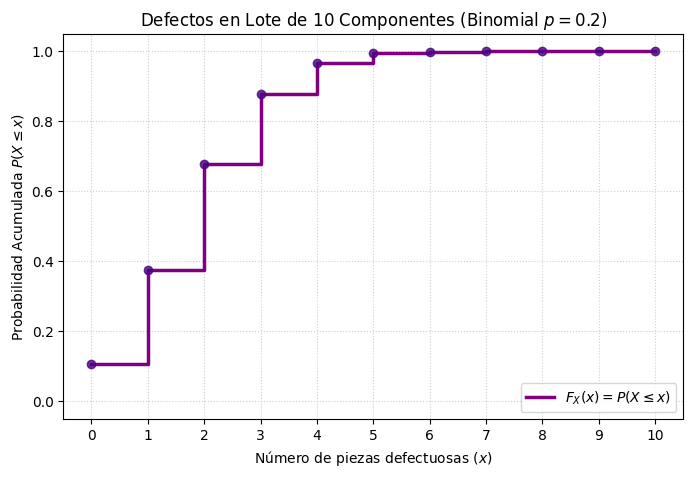

In [13]:
# Parámetros de la FMP Bernoulli
n_bin, p_bin = 10, 0.2
rango_bin = np.arange(0, n_bin + 1)
fda_bin = stats.binom.cdf(rango_bin, n_bin, p_bin)

plt.figure(figsize=(8, 5))
plt.step(rango_bin, fda_bin, where='post', color='purple', lw=2.5, label='$F_X(x) = P(X \leq x)$')
plt.plot(rango_bin, fda_bin, 'o', color='indigo', alpha=0.8)

plt.title(f"Defectos en Lote de {n_bin} Componentes (Binomial $p={p_bin}$)")
plt.xlabel("Número de piezas defectuosas ($x$)")
plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")
plt.xticks(rango_bin)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc='lower right')
plt.show()

### 2.7 Distribución Geométrica $Geom(p)$

#### Caracteristicas
- **Rango:** $R_X = \{1, 2, 3, \dots\}$
- **FMP:** $p_X(x) = (1-p)^{x-1} p, \quad x \in R_X$
- **FDA Formulario Cerrado:** $F_X(x) = 1 - (1-p)^{\lfloor x \rfloor}, \quad x \geq 1$
- **Esperanza:** $E[X] = \frac{1}{p}$
- **Varianza:** $Var(X) = \frac{1-p}{p^2}$
- **Pérdida de Memoria:** $P(X > s + t \mid X > s) = P(X > t) = (1-p)^t$

#### Ejercicio Práctico Resuelto
Se lanzan dos dados imparciales de forma repetida hasta que la suma de sus caras sea igual a $7$. La probabilidad de obtener un $7$ en cualquier lanzamiento es $p = 1/6$.
1. Calcule la probabilidad de requerir más de 4 lanzamientos usando la FDA.

**Desarrollo Analítico:**
- $P(X > 4) = 1 - P(X \leq 4) = 1 - F_X(4)$.
- Usando la FDA en forma cerrada: $F_X(4) = 1 - (1 - 1/6)^4 = 1 - (5/6)^4 = 1 - 0.4823 = 0.5177$.
- $P(X > 4) = 1 - 0.5177 = 0.4823$ (equivalente a $(5/6)^4$ directo por la probabilidad de fallo consecutivo).

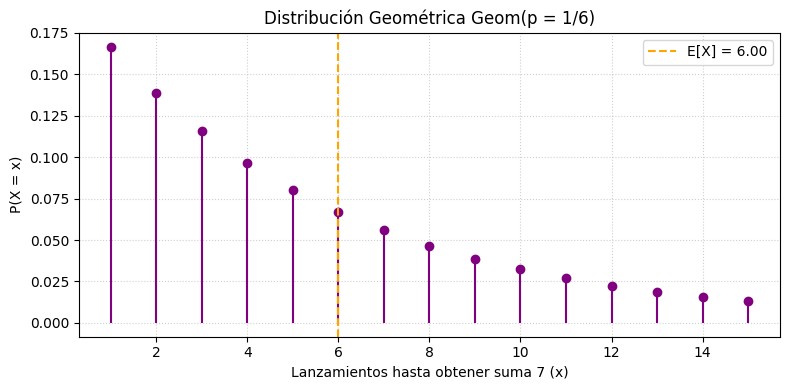

In [44]:
p_geom = 1/6
x_geom = np.arange(1, 16)
pmf_geom = stats.geom.pmf(x_geom, p_geom)

plt.figure(figsize=(8, 4))
plt.stem(x_geom, pmf_geom, basefmt=" ", linefmt='purple', markerfmt='Purple')
plt.axvline(x=1/p_geom, color='orange', linestyle='--', label=f'E[X] = {1/p_geom:.2f}')
plt.title("Distribución Geométrica Geom(p = 1/6)")
plt.xlabel("Lanzamientos hasta obtener suma 7 (x)")
plt.ylabel("P(X = x)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 2.8 Distribución Geométrica $Geom(p)$

### Problema (Bertsekas):
En un canal de comunicación digital, la probabilidad de transmitir con éxito un paquete de datos en un intento dado es $p = 0.35$. Las transmisiones son independientes. Sea $X$ el número de intentos requeridos hasta lograr la primera transmisión exitosa.

### Formalización Matemática:
- **Parámetro:** $p = 0.35$
- **Rango:** $R_X = \{1, 2, 3, \dots\}$
- **FMP:** $p_X(k) = (1 - 0.35)^{k-1} (0.35), \quad k \in R_X$
- **FDA:** $F_X(x) = 1 - (1 - 0.35)^{\lfloor x \rfloor}, \quad x \geq 1$

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\3707016150.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.step(rango_geom, fda_geom, where='post', color='darkorange', lw=2.5, label='$F_X(x) = P(X \leq x)$')
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\3707016150.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")


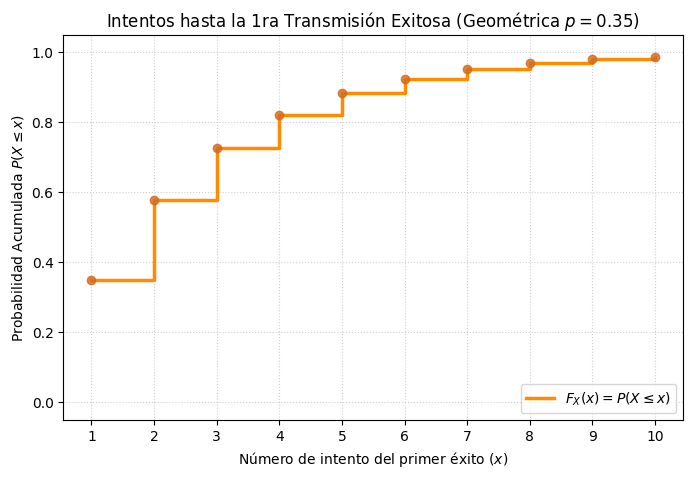

In [12]:
# Parámetros de la distribución geométrica
p_geom = 0.35
rango_geom = np.arange(1, 11)  # Evaluamos los primeros 10 intentos
fda_geom = stats.geom.cdf(rango_geom, p_geom)

plt.figure(figsize=(8, 5))
plt.step(rango_geom, fda_geom, where='post', color='darkorange', lw=2.5, label='$F_X(x) = P(X \leq x)$')
plt.plot(rango_geom, fda_geom, 'o', color='chocolate', alpha=0.8)

plt.title("Intentos hasta la 1ra Transmisión Exitosa (Geométrica $p=0.35$)")
plt.xlabel("Número de intento del primer éxito ($x$)")
plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")
plt.xticks(rango_geom)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc='lower right')
plt.show()

### 2.9 Distribución Poisson $Poisson(\lambda)$

#### Caracteristicas
- **Rango:** $R_X = \{0, 1, 2, \dots\}$
- **FMP:** $p_X(x) = \frac{e^{-\lambda} \lambda^x}{x!}, \quad x \in R_X$
- **FDA:** $F_X(x) = e^{-\lambda} \sum_{k=0}^{\lfloor x \rfloor} \frac{\lambda^k}{k!}, \quad x \geq 0$
- **Esperanza y Varianza:** $E[X] = \lambda, \quad Var(X) = \lambda$ 

#### Ejemplo
El número de erratas por página en la primera edición de un libro impreso sigue una distribución Poisson con parámetro $\lambda = 0.8$.
1. Calcule la probabilidad de que una página elegida al azar tenga al menos una errata.
2. Calcule $F_X(2)$.

**Desarrollo Analítico:**
- $P(X \geq 1) = 1 - P(X = 0) = 1 - F_X(0) = 1 - e^{-0.8} \approx 1 - 0.4493 = 0.5507$.
- $F_X(2) = P(X \leq 2) = e^{-0.8} \left( \frac{0.8^0}{0!} + \frac{0.8^1}{1!} + \frac{0.8^2}{2!} \right) = 0.4493 (1 + 0.8 + 0.32) = 0.4493 \times 2.12 = 0.9525$.

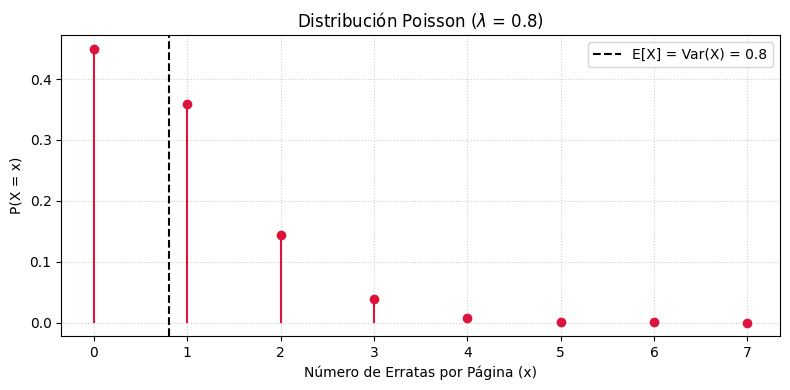

In [45]:
lam_poi = 0.8
x_poi = np.arange(0, 8)
pmf_poi = stats.poisson.pmf(x_poi, lam_poi)

plt.figure(figsize=(8, 4))
plt.stem(x_poi, pmf_poi, basefmt=" ", linefmt='crimson', markerfmt='Crimson')
plt.axvline(x=lam_poi, color='black', linestyle='--', label=f'E[X] = Var(X) = {lam_poi}')
plt.title(f"Distribución Poisson ($\\lambda$ = {lam_poi})")
plt.xlabel("Número de Erratas por Página (x)")
plt.ylabel("P(X = x)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 2.10 Distribución Poisson $Poisson(\lambda)$

### Problema (Ross):
El número de peticiones que llegan a un servidor web en un intervalo de un minuto sigue un proceso Poisson con una tasa promedio de $\lambda = 4$ peticiones por minuto. Sea $X$ el número de peticiones recibidas en un minuto determinado.

### Formalización Matemática:
- **Parámetro:** $\lambda = 4.0$
- **Rango:** $R_X = \{0, 1, 2, 3, \dots\}$
- **FMP:** $p_X(k) = \frac{e^{-4} 4^k}{k!}, \quad k \in R_X$
- **FDA:** $F_X(x) = \sum_{k=0}^{\lfloor x \rfloor} \frac{e^{-4} 4^k}{k!}$

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\399877906.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.step(rango_poi, fda_poi, where='post', color='crimson', lw=2.5, label='$F_X(x) = P(X \leq x)$')
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\399877906.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.title("FDA: Peticiones al Servidor por Minuto (Poisson $\lambda=4$)")
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\399877906.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")


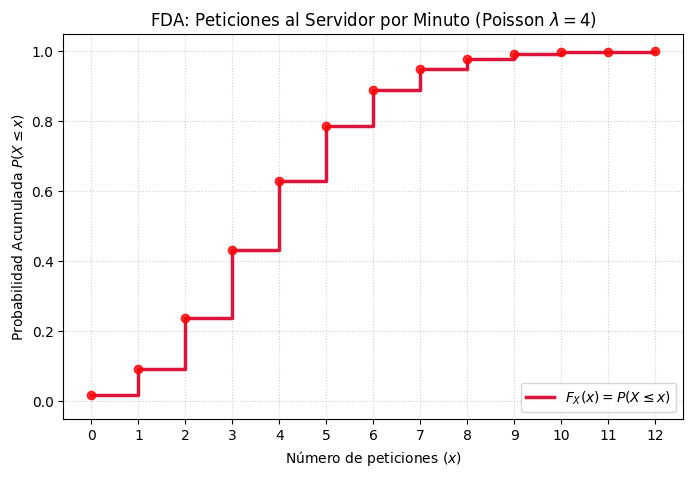

In [ ]:
# Parámetros distribucion Poisson acumulada 
lam_poi = 4.0
rango_poi = np.arange(0, 13)
fda_poi = stats.poisson.cdf(rango_poi, lam_poi)

plt.figure(figsize=(8, 5))
plt.step(rango_poi, fda_poi, where='post', color='crimson', lw=2.5, label='$F_X(x) = P(X \leq x)$')
plt.plot(rango_poi, fda_poi, 'ro', alpha=0.8)

plt.title("Peticiones al Servidor por Minuto (Poisson $\lambda=4$)")
plt.xlabel("Número de peticiones ($x$)")
plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")
plt.xticks(rango_poi)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc='lower right')
plt.show()

### 2.11 Distribución Binomial Negativa $BN(r, p)$

#### Caracteristicas
- **Rango:** $R_X = \{r, r+1, r+2, \dots\}$ *(representando el total de ensayos $x$)*
- **FMP:** $p_X(x) = \binom{x-1}{r-1} p^r (1-p)^{x-r}, \quad x \in R_X$
- **FDA:** $F_X(x) = \sum_{k=r}^{\lfloor x \rfloor} \binom{k-1}{r-1} p^r (1-p)^{k-r}, \quad x \geq r$
- **Esperanza:** $E[X] = \frac{r}{p}$
- **Varianza:** $Var(X) = \frac{r(1-p)}{p^2}$

#### Ejemplo
Un geólogo realiza perforaciones exploratorias en busca de petróleo. La probabilidad de éxito en cada perforación independiente es $p = 0.20$. Se detendrá al encontrar $r = 2$ pozos productivos.
1. Encuentre el número esperado de perforaciones requeridas.
2. Calcule la probabilidad de requerir exactamente 5 perforaciones ($P(X = 5)$).

**Desarrollo Analítico:**
- $E[X] = \frac{r}{p} = \frac{2}{0.20} = 10$ perforaciones.
- $P(X = 5) = \binom{5-1}{2-1} (0.20)^2 (0.80)^{5-2} = \binom{4}{1} (0.04) (0.512) = 4 \times 0.02048 = 0.08192$.

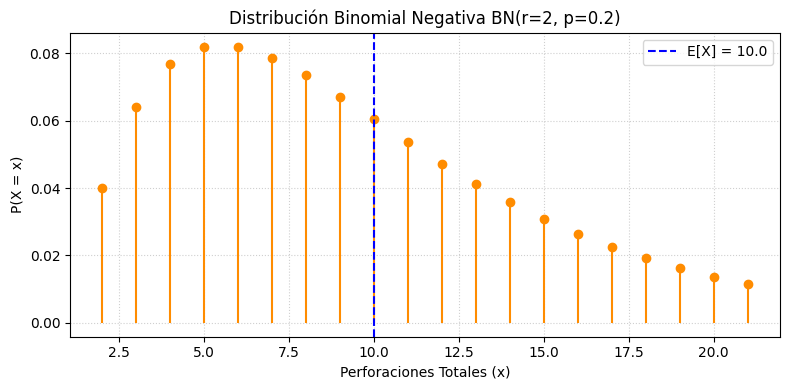

In [46]:
r_nb, p_nb = 2, 0.20
k_nb = np.arange(0, 20) # Excesos (x - r)
pmf_nb = stats.nbinom.pmf(k_nb, r_nb, p_nb)
x_nb = k_nb + r_nb

plt.figure(figsize=(8, 4))
plt.stem(x_nb, pmf_nb, basefmt=" ", linefmt='darkorange', markerfmt='DarkOrange')
plt.axvline(x=r_nb/p_nb, color='blue', linestyle='--', label=f'E[X] = {r_nb/p_nb}')
plt.title(f"Distribución Binomial Negativa BN(r={r_nb}, p={p_nb})")
plt.xlabel("Perforaciones Totales (x)")
plt.ylabel("P(X = x)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 2.12 Distribución Binomial Negativa $NB(r, p)$

### Problema (Bertsekas):
Un agente de ventas realiza llamadas telefónicas independientes para ofrecer una suscripción. La probabilidad de cerrar una venta en cada llamada es $p = 0.4$. Su meta diaria es concretar $r = 3$ ventas. Sea $X$ el número total de llamadas que debe realizar para alcanzar las 3 ventas.

### Formalización Matemática:
- **Parámetros:** $r = 3, p = 0.4$
- **Rango:** $R_X = \{3, 4, 5, \dots\}$
- **FMP:** $p_X(k) = \binom{k-1}{2} (0.4)^3 (0.6)^{k-3}, \quad k \in R_X$
- **FDA:** $F_X(x) = \sum_{k=3}^{\lfloor x \rfloor} \binom{k-1}{2} (0.4)^3 (0.6)^{k-3}$

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\940800115.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.step(rango_totales, fda_nb, where='post', color='darkcyan', lw=2.5, label='$F_X(x) = P(X \leq x)$')
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\940800115.py:14: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")


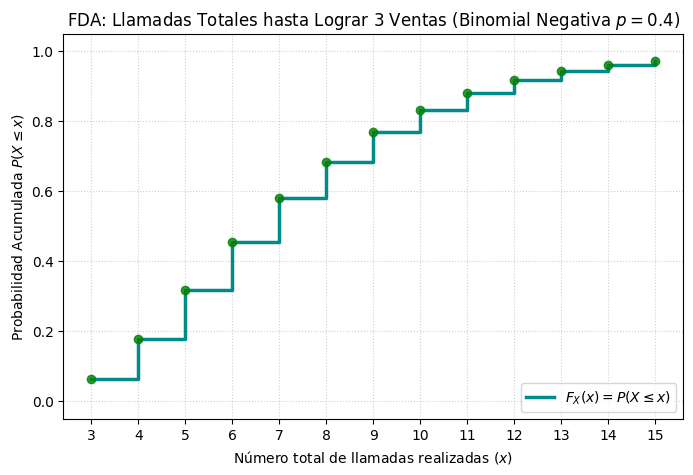

In [15]:
# Parámetros
r_nb, p_nb = 3, 0.4
rango_totales = np.arange(r_nb, 16)
# scipy.stats.nbinom requiere convertir ensayos totales a número de fracasos (k_fracasos = k_totales - r)
rango_fracasos = rango_totales - r_nb
fda_nb = stats.nbinom.cdf(rango_fracasos, r_nb, p_nb)

plt.figure(figsize=(8, 5))
plt.step(rango_totales, fda_nb, where='post', color='darkcyan', lw=2.5, label='$F_X(x) = P(X \leq x)$')
plt.plot(rango_totales, fda_nb, 'go', alpha=0.8)

plt.title(f"FDA: Llamadas Totales hasta Lograr {r_nb} Ventas (Binomial Negativa $p={p_nb}$)")
plt.xlabel("Número total de llamadas realizadas ($x$)")
plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")
plt.xticks(rango_totales)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc='lower right')
plt.show()

### 2.13 Distribución Hipergeométrica $Hyperg(N, K, n)$

#### Caracteristicas
- **Rango:** $\max(0, n - (N - K)) \leq x \leq \min(n, K)$
- **FMP:** $p_X(x) = \frac{\binom{K}{x} \binom{N-K}{n-x}}{\binom{N}{n}}$
- **FDA:** $F_X(x) = \sum_{k=0}^{\lfloor x \rfloor} \frac{\binom{K}{k} \binom{N-K}{n-k}}{\binom{N}{n}}$
- **Esperanza:** $E[X] = n \frac{K}{N}$
- **Varianza:** $Var(X) = n \frac{K}{N} \left(1 - \frac{K}{N}\right) \left(\frac{N - n}{N - 1}\right)$

#### Ejermplo:
Un grupo de $N = 20$ personas contiene $K = 8$ mujeres y $12$ hombres. Se selecciona una comisión al azar de $n = 5$ personas sin reemplazo.
1. Calcule la probabilidad de que la comisión contenga exactamente 2 mujeres.

**Desarrollo Analítico:**
- $P(X = 2) = \frac{\binom{8}{2} \binom{12}{3}}{\binom{20}{5}}$.
- $\binom{8}{2} = 28$, $\binom{12}{3} = 220$, $\binom{20}{5} = 15504$.
- $P(X = 2) = \frac{28 \times 220}{15504} = \frac{6160}{15504} \approx 0.3973$.

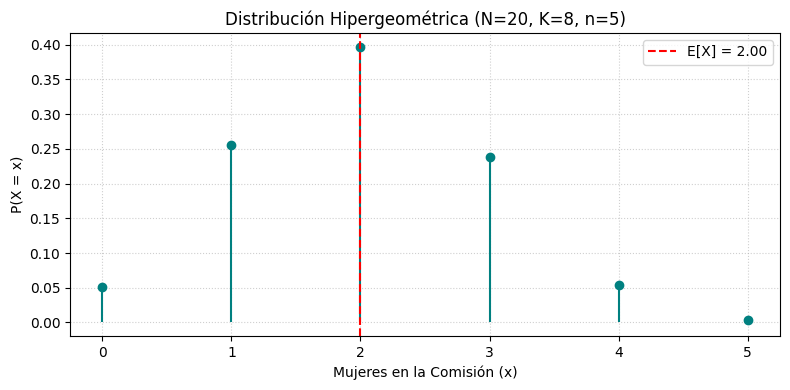

In [47]:
N_hyp, K_hyp, n_hyp = 20, 8, 5
x_hyp = np.arange(0, min(n_hyp, K_hyp) + 1)
pmf_hyp = stats.hypergeom.pmf(x_hyp, N_hyp, K_hyp, n_hyp)

plt.figure(figsize=(8, 4))
plt.stem(x_hyp, pmf_hyp, basefmt=" ", linefmt='teal', markerfmt='Teal')
plt.axvline(x=n_hyp*(K_hyp/N_hyp), color='red', linestyle='--', label=f'E[X] = {n_hyp*(K_hyp/N_hyp):.2f}')
plt.title(f"Distribución Hipergeométrica (N={N_hyp}, K={K_hyp}, n={n_hyp})")
plt.xlabel("Mujeres en la Comisión (x)")
plt.ylabel("P(X = x)")
plt.xticks(x_hyp)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 2.14 Distribución Hipergeométrica $Hyperg(N, K, n)$

### Problema (Ross):
Un contenedor contiene $N = 20$ componentes mecánicos, de los cuales $K = 6$ están defectuosos. Se selecciona una muestra aleatoria de $n = 5$ componentes **sin reemplazo** para su inspección. Sea $X$ el número de componentes defectuosos encontrados en la muestra.

### Formalización Matemática:
- **Parámetros:** $N = 20, K = 6, n = 5$
- **Rango:** $R_X = \{0, 1, 2, 3, 4, 5\}$
- **FMP:** $p_X(k) = \frac{\binom{6}{k} \binom{14}{5-k}}{\binom{20}{5}}, \quad k \in R_X$
- **FDA:** $F_X(x) = \sum_{k=0}^{\lfloor x \rfloor} \frac{\binom{6}{k} \binom{14}{5-k}}{\binom{20}{5}}$

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\3282740297.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.step(rango_hyp, fda_hyp, where='post', color='sienna', lw=2.5, label='$F_X(x) = P(X \leq x)$')
C:\Users\joseg\AppData\Local\Temp\ipykernel_20440\3282740297.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")


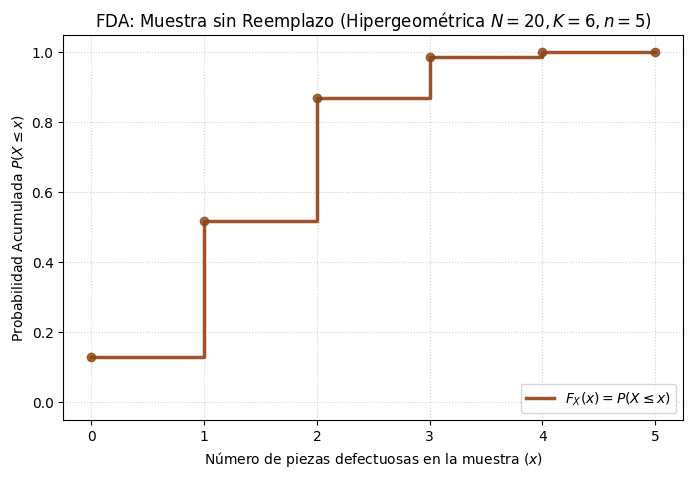

In [16]:
# Parámetros
N_tot, K_exitos, n_muestra = 20, 6, 5
rango_hyp = np.arange(0, min(n_muestra, K_exitos) + 1)
fda_hyp = stats.hypergeom.cdf(rango_hyp, N_tot, K_exitos, n_muestra)

plt.figure(figsize=(8, 5))
plt.step(rango_hyp, fda_hyp, where='post', color='sienna', lw=2.5, label='$F_X(x) = P(X \leq x)$')
plt.plot(rango_hyp, fda_hyp, 'o', color='saddlebrown', alpha=0.8)

plt.title(f"FDA: Muestra sin Reemplazo (Hipergeométrica $N={N_tot}, K={K_exitos}, n={n_muestra}$)")
plt.xlabel("Número de piezas defectuosas en la muestra ($x$)")
plt.ylabel("Probabilidad Acumulada $P(X \leq x)$")
plt.xticks(rango_hyp)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc='lower right')
plt.show()

---

## 3. Fundamentos de Variables Aleatorias Continuas

Una variable aleatoria continua $X$ posee una **Función de Densidad de Probabilidad (FDP / PDF)** $f_X(x)$ integrable sobre $\mathbb{R}$.

### Caracteristicas de unaa variable aleatoria continua
1. **FDP:** $f_X(x) \geq 0, \quad \forall x \in \mathbb{R}$ y $\int_{-\infty}^{\infty} f_X(x) dx = 1$.
2. **FDA (Función de Distribución Acumulada):**
   $$F_X(x) = P(X \leq x) = \int_{-\infty}^x f_X(u) du$$
   - Por el Teorema Fundamental del Cálculo: $f_X(x) = \frac{d}{dx} F_X(x)$ donde $F_X$ sea diferenciable.
   - Propiedad de Probabilidad por Intervalos: $P(a \leq X \leq b) = F_X(b) - F_X(a)$.

--- 

## 4. Distribuciones Continuas Clásicas

### 4.1 Distribución Uniforme Continua $U(a, b)$

#### Caracteristicas
- **FDP:** $f_X(x) = \begin{cases} \frac{1}{b - a} & a \leq x \leq b \\ 0 & \text{en otro caso} \end{cases}$
- **FDA:** $F_X(x) = \begin{cases} 0 & x < a \\ \frac{x - a}{b - a} & a \leq x \leq b \\ 1 & x > b \end{cases}$
- **Esperanza:** $E[X] = \frac{a + b}{2}$
- **Varianza:** $Var(X) = \frac{(b - a)^2}{12}$

#### Ejemplo:
Un autobús pasa por una estación cada $15$ minutos exactamente. Un pasajero llega a la estación en un momento completamente aleatorio. El tiempo de espera $X$ en minutos es $U(0, 15)$.
1. Obtenga la FDA $F_X(x)$.
2. Calcule la probabilidad de que el pasajero espere entre 5 y 10 minutos usando la FDA.

**Desarrollo Analítico:**
- Para $0 \leq x \leq 15$, $F_X(x) = \int_0^x \frac{1}{15} du = \frac{x}{15}$.
- $P(5 \leq X \leq 10) = F_X(10) - F_X(5) = \frac{10}{15} - \frac{5}{15} = \frac{5}{15} = \frac{1}{3} \approx 0.3333$.

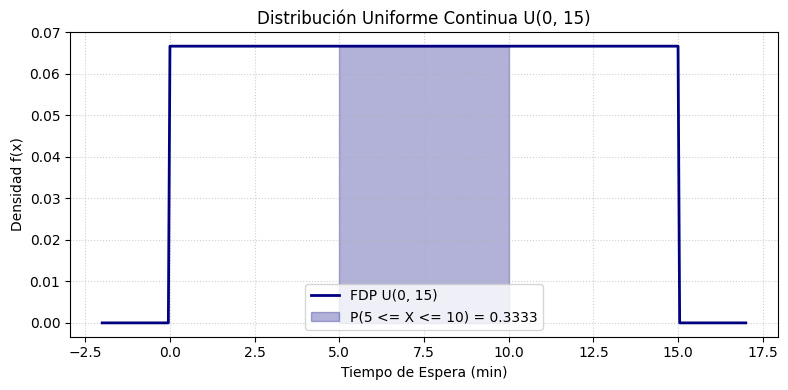

In [48]:
a_u, b_u = 0.0, 15.0
x_u = np.linspace(a_u - 2, b_u + 2, 400)
pdf_u = stats.uniform.pdf(x_u, loc=a_u, scale=b_u - a_u)

plt.figure(figsize=(8, 4))
plt.plot(x_u, pdf_u, 'navy', lw=2, label='FDP U(0, 15)')
plt.fill_between(x_u, pdf_u, where=(x_u >= 5) & (x_u <= 10), color='navy', alpha=0.3, label='P(5 <= X <= 10) = 0.3333')
plt.title("Distribución Uniforme Continua U(0, 15)")
plt.xlabel("Tiempo de Espera (min)")
plt.ylabel("Densidad f(x)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Distribución Normal $\mathcal{N}(\mu, \sigma^2)$

#### Caracteristicas
- **FDP:** $f_X(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{1}{2} \left( \frac{x - \mu}{\sigma} \right)^2 \right), \quad x \in \mathbb{R}$
- **FDA:** $F_X(x) = \Phi\left( \frac{x - \mu}{\sigma} \right) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\frac{x - \mu}{\sigma}} e^{-\frac{u^2}{2}} du$
- **Esperanza y Varianza:** $E[X] = \mu, \quad Var(X) = \sigma^2$

#### Ejemplo
La estatura de los alumnos de una universidad sigue una distribución normal con $\mu = 170$ cm y $\sigma = 10$ cm.
1. Calcule $P(X > 185)$ expresando la solución en términos de la FDA de la normal estándar $\Phi(z)$.

**Desarrollo Analítico:**
- $P(X > 185) = 1 - P(X \leq 185) = 1 - F_X(185)$.
- Estandarizando: $Z = \frac{185 - 170}{10} = 1.5$.
- $1 - F_X(185) = 1 - \Phi(1.5)$.
- De tablas normales: $\Phi(1.5) \approx 0.9332$.
- $P(X > 185) = 1 - 0.9332 = 0.0668$ ($6.68\%$).

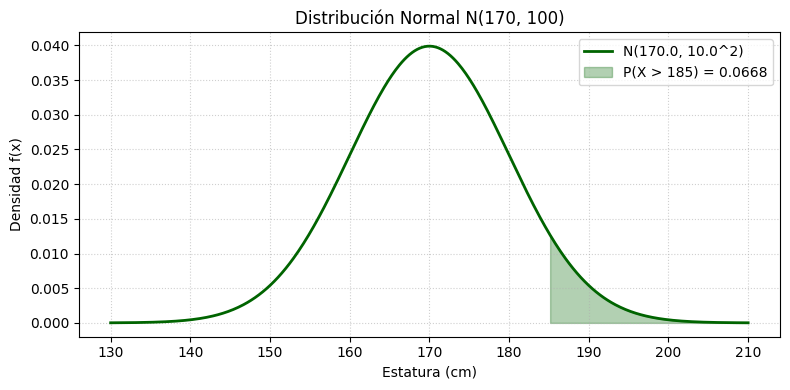

In [49]:
mu_n, sigma_n = 170.0, 10.0
x_n = np.linspace(mu_n - 4*sigma_n, mu_n + 4*sigma_n, 500)
pdf_n = stats.norm.pdf(x_n, loc=mu_n, scale=sigma_n)

plt.figure(figsize=(8, 4))
plt.plot(x_n, pdf_n, 'darkgreen', lw=2, label=f'N({mu_n}, {sigma_n}^2)')
plt.fill_between(x_n, pdf_n, where=(x_n >= 185), color='darkgreen', alpha=0.3, label='P(X > 185) = 0.0668')
plt.title("Distribución Normal N(170, 100)")
plt.xlabel("Estatura (cm)")
plt.ylabel("Densidad f(x)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 4.3 Distribución Exponencial $Exp(\lambda)$

#### Caracteristicas
- **FDP:** $f_X(x) = \begin{cases} \lambda e^{-\lambda x} & x \geq 0 \\ 0 & x < 0 \end{cases}$
- **FDA Formulario Cerrado:** $F_X(x) = \begin{cases} 1 - e^{-\lambda x} & x \geq 0 \\ 0 & x < 0 \end{cases}$
- **Esperanza:** $E[X] = \frac{1}{\lambda}$
- **Varianza:** $Var(X) = \frac{1}{\lambda^2}$
- **Propiedad de Falta de Memoria:** $P(X > s + t \mid X > s) = P(X > t) = e^{-\lambda t}$

#### Ejemplo:
El tiempo de duración en horas de una llamada telefónica sigue una distribución exponencial con parámetro $\lambda = 1/10$ (duración media de $10$ minutos).
1. Determine la FDA explícita del tiempo de llamada.
2. Calcule la probabilidad de que una llamada dure entre $5$ y $15$ minutos usando la FDA.

**Desarrollo Analítico:**
- $F_X(x) = 1 - e^{-x/10}$ para $x \geq 0$.
- $P(5 \leq X \leq 15) = F_X(15) - F_X(5) = (1 - e^{-15/10}) - (1 - e^{-5/10}) = e^{-0.5} - e^{-1.5}$.
- $e^{-0.5} \approx 0.6065$, $e^{-1.5} \approx 0.2231$.
- $P(5 \leq X \leq 15) = 0.6065 - 0.2231 = 0.3834$.

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
C:\Users\joseg\AppData\Local\Temp\ipykernel_21284\3707195823.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x_exp, pdf_exp, 'firebrick', lw=2, label='Exp($\lambda$=0.1)')


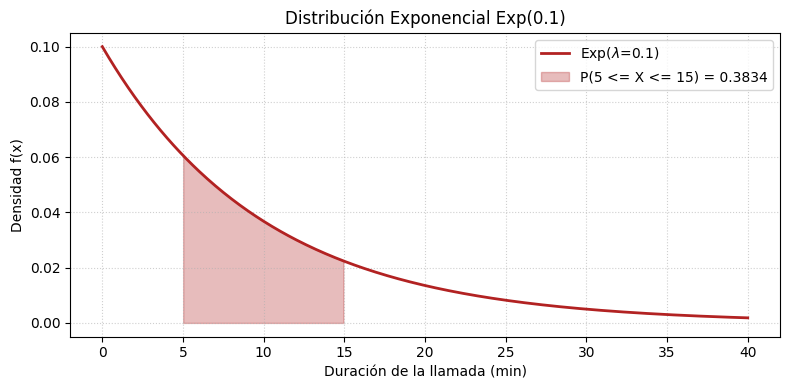

In [50]:
lam_exp = 1/10
x_exp = np.linspace(0, 40, 400)
pdf_exp = stats.expon.pdf(x_exp, scale=1/lam_exp)

plt.figure(figsize=(8, 4))
plt.plot(x_exp, pdf_exp, 'firebrick', lw=2, label='Exp($\lambda$=0.1)')
plt.fill_between(x_exp, pdf_exp, where=(x_exp >= 5) & (x_exp <= 15), color='firebrick', alpha=0.3, label='P(5 <= X <= 15) = 0.3834')
plt.title("Distribución Exponencial Exp(0.1)")
plt.xlabel("Duración de la llamada (min)")
plt.ylabel("Densidad f(x)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 4.4 Distribución Gamma $Gamma(\alpha, \beta)$

#### Caracteristicas
- **FDP:** $f_X(x) = \begin{cases} \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha - 1} e^{-\beta x} & x > 0 \\ 0 & x \leq 0 \end{cases}$
- **FDA:** $F_X(x) = \frac{\gamma(\alpha, \beta x)}{\Gamma(\alpha)}, \quad x > 0$ *(donde $\gamma$ es la función gamma incompleta inferior)*
- **Esperanza:** $E[X] = \frac{\alpha}{\beta}$
- **Varianza:** $Var(X) = \frac{\alpha}{\beta^2}$

#### Ejemplo:
El tiempo total en años para que un sistema presente $\alpha = 2$ fallas sigue una distribución Gamma con parámetro de tasa $\beta = 1$ falla/año (equivalente a la suma de 2 exponenciales independientes).
1. Encuentre la FDA analítica integrada paso a paso mediante integración por partes.
2. Calcule la probabilidad de que la segunda falla ocurra antes del primer año ($F_X(1)$).

**Desarrollo Analítico:**
- $f_X(x) = \frac{1^2}{\Gamma(2)} x^{2-1} e^{-1 \cdot x} = x e^{-x}$ para $x > 0$.
- $F_X(x) = \int_0^x u e^{-u} du$.
  - Aplicando integración por partes ($u = u \implies du = du$; $dv = e^{-u}du \implies v = -e^{-u}$):
  - $F_X(x) = \left[ -u e^{-u} \right]_0^x - \int_0^x (-e^{-u}) du = -x e^{-x} - \left[ e^{-u} \right]_0^x = -x e^{-x} - e^{-x} + 1 = 1 - e^{-x}(1 + x)$.
- Evaluando en $x = 1$: $F_X(1) = 1 - e^{-1}(1 + 1) = 1 - 2e^{-1} \approx 1 - 2(0.3679) = 1 - 0.7358 = 0.2642$.

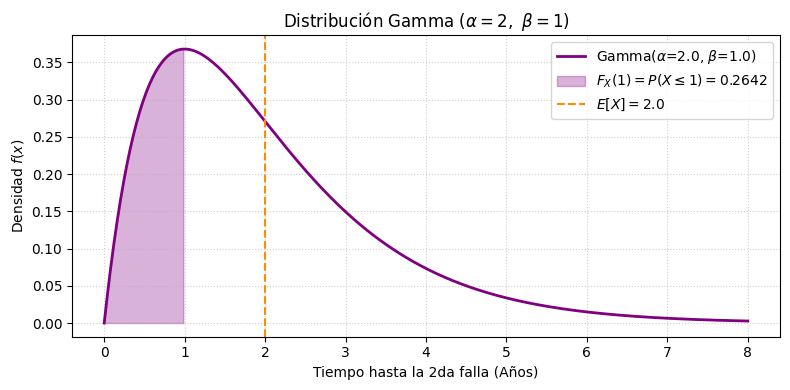

In [51]:
alpha_g, beta_g = 2.0, 1.0

x_g = np.linspace(0, 8, 400)
pdf_g = stats.gamma.pdf(x_g, a=alpha_g, scale=1/beta_g)

cdf = stats.gamma.cdf(1, a=alpha_g, scale=1/beta_g)

plt.figure(figsize=(8, 4))

plt.plot(x_g, pdf_g, 'purple', lw=2,
         label=rf'Gamma($\alpha$={alpha_g}, $\beta$={beta_g})')

plt.fill_between(x_g, pdf_g, where=(x_g <= 1),
                 color='purple', alpha=0.3,
                 label=rf'$F_X(1)=P(X\leq1)={cdf:.4f}$')

plt.axvline(x=alpha_g/beta_g, color='darkorange',
            linestyle='--',
            label=rf'$E[X]={alpha_g/beta_g}$')

plt.title(r"Distribución Gamma ($\alpha=2,\ \beta=1$)")
plt.xlabel("Tiempo hasta la 2da falla (Años)")
plt.ylabel("Densidad $f(x)$")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

---

## 5. Método de Transformación Inversa para Generación de Variables Aleatorias

El **Método de la Transformada Inversa** (Ross, Cap. 10 / Bertsekas, Cap. 8) es el algoritmo fundamental para simular observaciones de una variable aleatoria continua $X$ con Función de Distribución Acumulada (FDA) estrictamente creciente y continua $F_X(x)$.

### Teorema Fundamental (Teorema de la Transformación Integral de Probabilidad):
Sea $U \sim U(0, 1)$ una variable aleatoria continua uniforme en el intervalo $(0, 1)$. Si definimos la variable aleatoria $X$ mediante la transformación:
$$X = F_X^{-1}(U)$$
entonces la variable aleatoria resultando $X$ tiene exactamente a $F_X(x)$ como su FDA.

#### Demostración Analítica:
$$P(X \leq x) = P(F_X^{-1}(U) \leq x)$$
Como $F_X$ es una función no decreciente, aplicamos $F_X$ a ambos lados de la desigualdad:
$$P(F_X(F_X^{-1}(U)) \leq F_X(x)) = P(U \leq F_X(x))$$
Recordando que para $U \sim U(0, 1)$, $P(U \leq u) = u$ para todo $u \in [0, 1]$:
$$P(U \leq F_X(x)) = F_X(x)$$
Q.E.D.

---

### Ejercicio de Simulación Inversa: Distribución Exponencial $Exp(\lambda)$
Para $X \sim Exp(\lambda)$, su FDA es $F_X(x) = 1 - e^{-\lambda x}$ para $x \geq 0$.
1. Igualamos a $U$: $U = 1 - e^{-\lambda X}$.
2. Despejamos $X$: $1 - U = e^{-\lambda X} \implies \ln(1 - U) = -\lambda X \implies X = -\frac{1}{\lambda} \ln(1 - U)$.
3. Como $1 - U$ también se distribuye como $U(0, 1)$, se suele simplificar a: $X = -\frac{1}{\lambda} \ln(U)$.

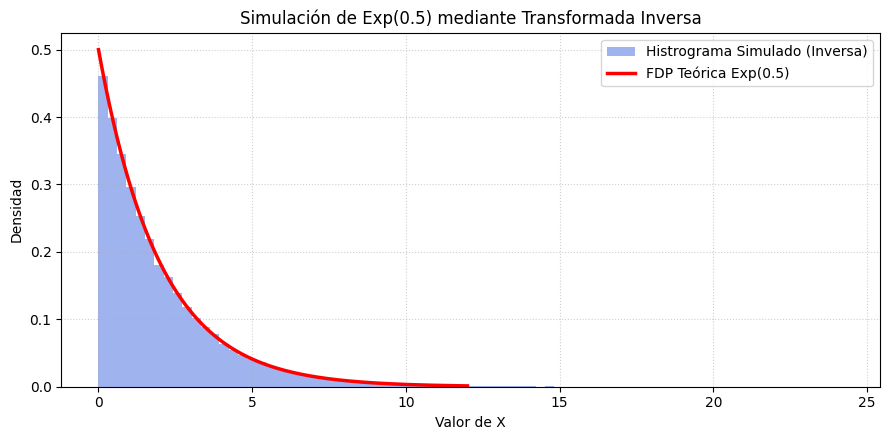

In [52]:
# Fijamos la semilla para que siempre salgan los mismos numeros al correrlo
np.random.seed(42)

lam = 0.5 # Tasa lambda de nuestra exponencial
N_sim = 100000 # Un numero decente de simulaciones para ver el ajuste

# 1. Generamos los uniformes U(0,1)
u = np.random.uniform(0, 1, N_sim)

# 2. Aplicamos la formula del metodo de la transformada inversa
x_simulados = -np.log(u) / lam

# Graficamos para comparar la simulacion vs la teoria
plt.figure(figsize=(9, 4.5))
x_teorico = np.linspace(0, 12, 500)
pdf_teorica = stats.expon.pdf(x_teorico, scale=1/lam)

# Dibujamos el histograma con densidad=True para que quede normalizado
plt.hist(x_simulados, bins=80, density=True, alpha=0.5, color='royalblue', label='Histrograma Simulado (Inversa)')
plt.plot(x_teorico, pdf_teorica, 'r-', lw=2.5, label='FDP Teórica Exp(0.5)')
plt.title("Simulación de Exp(0.5) mediante Transformada Inversa", fontsize=12)
plt.xlabel("Valor de X")
plt.ylabel("Densidad")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

---
## Veamos otro ejemplo de Transformaciones Inversas:
### 5.1 Transformada Inversa: Ejemplo tomado de (Ross, Cap. 10)

**Problema:** Queremos simular observaciones de una variable aleatoria continua $X$ con densidad triangular dada por $f_X(x) = 2x$ para $x \in [0, 1]$.

#### Paso 1: Obtener la FDA ($F_X(x)$)
$$F_X(x) = \int_{0}^{x} 2t \, dt = x^2, \quad x \in [0, 1]$$

#### Paso 2: Invertir la FDA ($F_X^{-1}(u)$)
Igualamos $u = F_X(x)$ donde $u \sim U(0, 1)$:
$$u = x^2 \implies x = \sqrt{u}$$

Por lo tanto, el generador para $X$ es simplemente $X = \sqrt{U}$.

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
C:\Users\joseg\AppData\Local\Temp\ipykernel_21284\1144909497.py:13: SyntaxWarning: invalid escape sequence '\s'
  plt.hist(x_sim, bins=60, density=True, alpha=0.6, color='teal', edgecolor='black', label='Simulado ($X = \sqrt{U}$)')


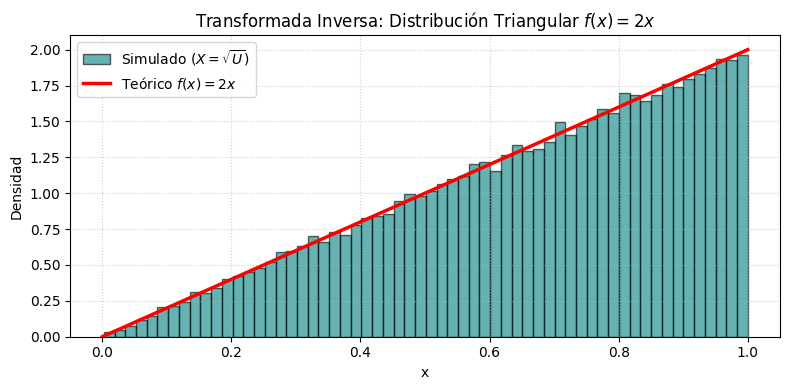

In [53]:
np.random.seed(42) #definiendo la semilla de reproductibilidad
N = 50000 #Numero de simulaciones

#  Generamos uniformes U(0,1)
u = np.random.uniform(0, 1, N)

# Inversa de la FDA: X = sqrt(U)
x_sim = np.sqrt(u)

# Visualizamos el resultado
plt.figure(figsize=(8, 4))
x_teorico = np.linspace(0, 1, 200)
plt.hist(x_sim, bins=60, density=True, alpha=0.6, color='teal', edgecolor='black', label='Simulado ($X = \sqrt{U}$)')
plt.plot(x_teorico, 2 * x_teorico, 'r-', lw=2.5, label='Teórico $f(x) = 2x$')
plt.title("Transformada Inversa: Distribución Triangular $f(x)=2x$", fontsize=12)
plt.xlabel("x")
plt.ylabel("Densidad")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Método de Aceptación y Rechazo; simulación de distibución Beta (Tomado de Bertsekas, cap. 8)

#### Idea Intuitiva:
Queremos generar observaciones de una variable $X \sim Beta(\alpha=2, \beta=1.5)$ con densidad objetivo $f(x)$, pero no tenemos una función inversa simple $F^{-1}(u)$. 

En su lugar, encerraremos la densidad $f(x)$ dentro de un "techo" uniforme $M \cdot g(x)$, donde $g(x) = 1$ en $[0, 1]$ es una propuesta $U(0,1)$ y $M$ es la altura máxima que alcanza $f(x)$.

#### Paso 1: Determinación de la Cota Superior $M$
La densidad objetivo es:
$f(x) = \frac{1}{B(2, 1.5)} x^{2-1}(1-x)^{1.5-1} = \frac{\Gamma(3.5)}{\Gamma(2)\Gamma(1.5)} x \sqrt{1-x}$


Derivando e igualando a cero, encontramos que el máximo de la función ocurre en la moda:
$$x^* = \frac{2-1}{(2-1) + (1.5-1)} = \frac{2}{3} \approx 0.6666$$

Evaluando en la FDP, la constante óptima $M$ es:
$$M = f(x^*) = f\left(\frac{2}{3}\right) \approx 1.4433$$

#### Algoritmo Paso a Paso:
1. **Proponer función candidata:** Generar $Y \sim U(0, 1)$.
2. **Generar nivel de prueba:** Generar $U \sim U(0, 1)$.
3. **Criterio de Aceptación:** 
   $$\text{Si } U \leq \frac{f(Y)}{M \cdot g(Y)} = \frac{f(Y)}{1.4433}, \quad \text{aceptamos } X = Y.$$
   De lo contrario, **rechazamos** $Y$ y repetimos el intento.

*(La tasa teórica de aceptación del algoritmo es $\frac{1}{M} = \frac{1}{1.4433} \approx 69.28\%$)*

Tasa de aceptación observada: 69.82% (Teórico 1/M = 69.28%)


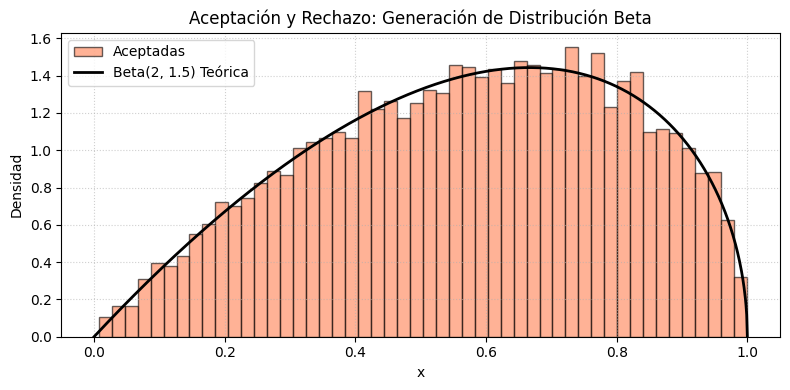

In [54]:
np.random.seed(123)
a, b = 2.0, 1.5 #parámetros de la función Beta
f_target = lambda x: stats.beta.pdf(x, a, b)

# Encontramos el maximo M numericamente de forma rapida
x_vals = np.linspace(0, 1, 1000)
M = np.max(f_target(x_vals))

muestras_aceptadas = []
total_intentos = 0
meta = 10000

while len(muestras_aceptadas) < meta:
    # Proponemos valores Y ~ U(0,1) y la prueba U ~ U(0,1)
    y_propuesto = np.random.uniform(0, 1)
    u_prueba = np.random.uniform(0, 1)
    total_intentos += 1
    
    # Condicion de aceptacion
    if u_prueba <= f_target(y_propuesto) / M:
        muestras_aceptadas.append(y_propuesto)

tasa_aceptacion = meta / total_intentos
print(f"Tasa de aceptación observada: {tasa_aceptacion:.2%} (Teórico 1/M = {1/M:.2%})")

plt.figure(figsize=(8, 4))
plt.hist(muestras_aceptadas, bins=50, density=True, alpha=0.6, color='coral', edgecolor='black', label='Aceptadas')
plt.plot(x_vals, f_target(x_vals), 'k-', lw=2, label='Beta(2, 1.5) Teórica')
plt.title("Aceptación y Rechazo: Generación de Distribución Beta", fontsize=12)
plt.xlabel("x")
plt.ylabel("Densidad")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

---

## 6. Función generadora de Momentos y Función Característica

### 6.1 Función Generadora de Momentos (FGM / MGF)
La FGM de una variable aleatoria $X$ se define como el valor esperado de $e^{tX}$:
$$M_X(t) = E[e^{tX}]$$
existiendo para todo $t$ en un entorno abierto alrededor de $t = 0$.

- **Generación de Momentos:** El $k$-ésimo momento no central de $X$ se obtiene mediante la $k$-ésima derivada evaluada en $t=0$:
  $$E[X^k] = M_X^{(k)}(0) = \left. \frac{d^k M_X(t)}{dt^k} \right|_{t=0}$$

### Ejercicio : Cálculo de Momentos y Suma de Variables Independientes via FGM (Ross, Cap. 7)

Sean $X_1 \sim Poisson(\lambda_1)$ y $X_2 \sim Poisson(\lambda_2)$ variables aleatorias independientes (v.a.i.).
Queremos encontrar la distribución de $Y = X_1 + X_2$.

**Demostración por FGM:**
1. La FGM de una Poisson de parámetro $\lambda$ es $M_X(t) = \exp(\lambda(e^t - 1))$.
2. Por independencia de $X_1$ y $X_2$:
$$M_Y(t) = M_{X_1 + X_2}(t) = M_{X_1}(t) \cdot M_{X_2}(t)$$
$$M_Y(t) = \exp(\lambda_1(e^t - 1)) \cdot \exp(\lambda_2(e^t - 1)) = \exp((\lambda_1 + \lambda_2)(e^t - 1))$$

Por la **propiedad de unicidad** de la FGM, $Y$ se distribuye exactamente como una $Poisson(\lambda_1 + \lambda_2)$.

In [55]:
import sympy as sp

# Definimos variables simbolicas para calcular momentos exactos
t, lam= sp.symbols('t lam', real=True, positive=True)
M_t = sp.exp(lam * (sp.exp(t) - 1))

# Derivada 1 para E[X]
d1 = sp.diff(M_t, t)
E_X = d1.subs(t, 0)

# Derivada 2 para E[X^2]
d2 = sp.diff(M_t, t, 2)
E_X2 = d2.subs(t, 0)
Var_X = E_X2 - (E_X**2)

print(f"E[X] derivado analíticamente de FGM: {sp.simplify(E_X)}")
print(f"Var(X) derivada analíticamente de FGM: {sp.simplify(Var_X)}")

E[X] derivado analíticamente de FGM: lam
Var(X) derivada analíticamente de FGM: lam


---

### 6.2 Función Característica (FC)
A diferencia de la FGM, la **Función Característica** se define mediante la unidad imaginaria $i = \sqrt{-1}$:
$$\phi_X(t) = E[e^{i t X}] = E[\cos(tX)] + i E[\sin(tX)]$$

- **Propiedad de Existencia Universal:** Ya que $|e^{i t X}| = 1$, la integral o suma para $\phi_X(t)$ **siempre converge absolutamente** para cualquier variable aleatoria $X$, sin importar si sus momentos o su FGM existen (como sucede con la distribución Cauchy).

| Distribución | FGM $M_X(t)$ | Función Característica $\phi_X(t)$ | Dominio de Existencia de FGM |
| :--- | :--- | :--- | :--- |
| **Bernoulli $Bern(p)$** | $1-p+pe^t$ | $1-p+pe^{it}$ | $t\in\mathbb{R}$ |
| **Binomial $Bin(n,p)$** | $(1-p+pe^t)^n$ | $(1-p+pe^{it})^n$ | $t\in\mathbb{R}$ |
| **Poisson $Poisson(\lambda)$** | $\exp(\lambda(e^t-1))$ | $\exp(\lambda(e^{it}-1))$ | $t\in\mathbb{R}$ |
| **Normal $\mathcal{N}(\mu,\sigma^2)$** | $\exp(\mu t+\frac{1}{2}\sigma^2t^2)$ | $\exp(i\mu t-\frac{1}{2}\sigma^2t^2)$ | $t\in\mathbb{R}$ |
| **Exponencial $Exp(\lambda)$** | $\frac{\lambda}{\lambda-t}$ | $\frac{\lambda}{\lambda-it}$ | $t<\lambda$ |
| **Cauchy $(x_0,\gamma)$** | No existe |  $\phi_X(t)=e^{i x_0 t-\gamma \lvert t\rvert}$ | No existe |

## 6.3 **Notas adicionales:** Conexión Integral con las transformadas de Laplace y Fourier

Un resultado fundamental aplicado en el análisis estocástico y finanzas cuantitativas es que las funciones generadoras no son más que adaptaciones probabilísticas de las transformadas integrales clásicas del análisis matemático; como lo son la transformada de Laplace y la transformada de Fourier.

### 6.3.1 La FGM es la Transformada Bilateral de Laplace
La **Transformada de Laplace Bilateral** de una función $f(x)$ se define como:
$$\mathcal{L}\{f(x)\}(s) = \int_{-\infty}^{\infty} e^{-sx} f(x) \, dx$$

Si evaluamos la FGM de una variable aleatoria $X$ con FDP $f_X(x)$:
$$M_X(t) = E[e^{tX}] = \int_{-\infty}^{\infty} e^{tx} f_X(x) \, dx$$

Haciendo la sustitución $s = -t$, tenemos la relación directa:
$$M_X(t) = \mathcal{L}\{f_X(x)\}(-t)$$

### 6.3.2 La Función Característica (FC) es la Transformada Inversa de Fourier
La **Transformada de Fourier** de una densidad $f_X(x)$ se define típicamente como:
$$\mathcal{F}\{f_X(x)\}(\omega) = \int_{-\infty}^{\infty} e^{-i \omega x} f_X(x) \, dx$$

Por otro lado, la **Función Característica** de $X$ se expresa como:
$$\phi_X(t) = E[e^{i t X}] = \int_{-\infty}^{\infty} e^{i t x} f_X(x) \, dx$$

Relación equivalente:
$$\phi_X(t) = \mathcal{F}\{f_X(x)\}(-t)$$

### ¿Y esto para qué nos sirve en la vida real? (Aterrizando la teoría)

A primera vista, la **Función Característica (FC)** parece una función con números imaginarios ($i$). Sin embargo, tiene una ventaja brutal sobre la FGM: **siempre existe**, sin importar la función con la que estemos trabajando (incluso si no tiene momentos finitos, como la distribución Cauchy).

Pero lo fuerte, es que la FC tiene una relación directa con la **Transformada Inversa de Fourier**. Esto nos da una herramienta matemática: si conocemos la función característica de una variable, podemos recuperar su densidad original $f_X(x)$ integrando en el plano complejo:

$$f_X(x) = \frac{1}{2\pi} \int_{-\infty}^{\infty} e^{-i t x} \phi_X(t) \, dt$$

#### ¿Por qué esto es clave en la práctica?
1. **Valuación Financiera Avanzada:** En finanzas cuantitativas, muchos modelos de activos (como el modelo de volatilidad estocástica de *Heston*) no tienen una fórmula cerrada para su densidad de probabilidad, pero **sí conocemos su Función Característica**.
2. **Algoritmos Rápidos (FFT):** Gracias a la relación con Fourier, podemos aplicar la **Transformada Rápida de Fourier (FFT)** (como en el famoso algoritmo de *Carr-Madan*) para simular y valuar miles de opciones financieras en milisegundos, en lugar de tardar horas haciendo simulaciones Monte Carlo tradicionales.

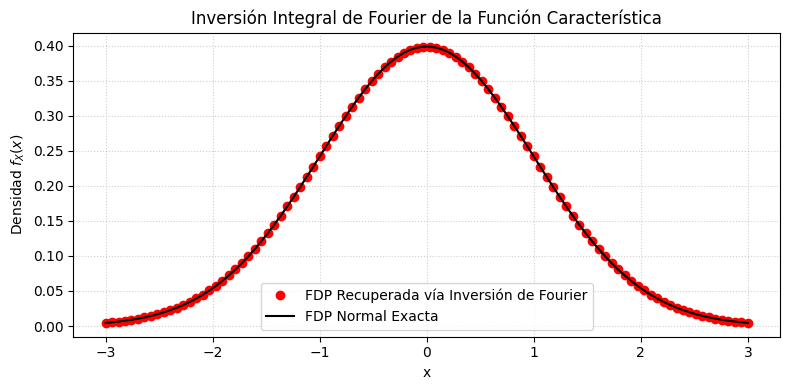

In [56]:
# Recuperacion de la FDP Normal N(0,1) invirtiendo la FC de forma numerica via Integracion
import scipy.integrate as integrate

# FC teórica de una N(0,1): phi(t) = exp(-0.5 * t^2)
phi_normal = lambda t: np.exp(-0.5 * t**2)

# Inversion de Fourier para obtener f_X(x)
def densidad_recuperada(x):
    # La parte imaginaria se anula por simetria, integramos solo la parte real
    integrando = lambda t: np.real(np.exp(-1j * t * x) * phi_normal(t))
    res, _ = integrate.quad(integrando, -np.inf, np.inf)
    return res / (2 * np.pi)

grid_x = np.linspace(-3, 3, 100)
f_recuperada = [densidad_recuperada(x) for x in grid_x]
f_teorica = stats.norm.pdf(grid_x)

plt.figure(figsize=(8, 4))
plt.plot(grid_x, f_recuperada, 'ro', label='FDP Recuperada vía Inversión de Fourier')
plt.plot(grid_x, f_teorica, 'k-', lw=1.5, label='FDP Normal Exacta')
plt.title("Inversión Integral de Fourier de la Función Característica", fontsize=12)
plt.xlabel("x")
plt.ylabel("Densidad $f_X(x)$")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

---

## 7. Leyes de los Grandes Números (LGN)

Sean $X_1, X_2, \dots, X_n$ variables aleatorias independientes e idénticamente distribuidas (i.i.d.) con esperanza finita $E[X_i] = \mu$. Definimos la media muestral como:
$$\bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i$$

### 7.1 Ley Débil de los Grandes Números (LDGN)
Establece la **convergencia en probabilidad** de la media muestral hacia la media poblacional $\mu$:
$$\lim_{n \to \infty} P(|\bar{X}_n - \mu| \geq \epsilon) = 0, \quad \forall \epsilon > 0$$

#### Demostración Corta (asumiendo varianza finita $\sigma^2 < \infty$):
Por las propiedades de la esperanza y varianza de la media muestral:
$$E[\bar{X}_n] = \mu, \quad Var(\bar{X}_n) = \frac{\sigma^2}{n}$$
Aplicando la **Desigualdad de Chebyshev** sobre $\bar{X}_n$:
$$P(|\bar{X}_n - \mu| \geq \epsilon) \leq \frac{Var(\bar{X}_n)}{\epsilon^2} = \frac{\sigma^2}{n \epsilon^2}$$
Tomando el límite cuando $n \to \infty$:
$$\lim_{n \to \infty} \frac{\sigma^2}{n \epsilon^2} = 0 \implies \lim_{n \to \infty} P(|\bar{X}_n - \mu| \geq \epsilon) = 0$$
Q.E.D.

---
### 7.2. Otra demostración del TLC vía FC, tomado de Ross.


Sean $X_1, \dots, X_n$ variables aleatorias independientes e identicamente distribuidas con $E[X_i] = 0$ y $Var(X_i) = 1$ (estandarizadas). Queremos ver el límite de $Z_n = \frac{\sum X_i}{\sqrt{n}}$.

1. La FC de una variable $X_i$ expandida en Serie de Taylor alrededor de $t=0$ es:
$$\phi_X(t) = E[e^{i t X}] = 1 + i t E[X] + \frac{(i t)^2}{2!} E[X^2] + o(t^2) = 1 - \frac{t^2}{2} + o(t^2)$$

2. La FC de $Z_n = \sum_{i=1}^n \frac{X_i}{\sqrt{n}}$ por independencia es:
$$\phi_{Z_n}(t) = \left( \phi_X\left( \frac{t}{\sqrt{n}} \right) \right)^n = \left( 1 - \frac{t^2}{2n} + o\left(\frac{t^2}{n}\right) \right)^n$$

3. Tomando el límite cuando $n \to \infty$, usando la propiedad $\lim_{n \to \infty} \left(1 + \frac{x}{n}\right)^n = e^x$:
$$\lim_{n \to \infty} \phi_{Z_n}(t) = e^{-\frac{t^2}{2}}$$

La cual es exactamente la Función Característica de una **Normal Estándar $\mathcal{N}(0,1)$**.
Por el **Teorema de Continuidad de Lévy**, la convergencia de las FC implica la **convergencia en distribución** $Z_n \xrightarrow{d} \mathcal{N}(0,1)$. Q.E.D.

---

## 7. Leyes de los Grandes Números (LGN)

Sean $X_1, X_2, \dots, X_n$ variables aleatorias independientes e idénticamente distribuidas (i.i.d.) con esperanza finita $E[X_i] = \mu$. Definimos la media muestral como:
$$\bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i$$

### 7.1 Ley Débil de los Grandes Números (LDGN)
Establece la **convergencia en probabilidad** de la media muestral hacia la media poblacional $\mu$:
$$\lim_{n \to \infty} P(|\bar{X}_n - \mu| \geq \epsilon) = 0, \quad \forall \epsilon > 0$$

#### Demostración Corta (asumiendo varianza finita $\sigma^2 < \infty$):
Por las propiedades de la esperanza y varianza de la media muestral:
$$E[\bar{X}_n] = \mu, \quad Var(\bar{X}_n) = \frac{\sigma^2}{n}$$
Aplicando la **Desigualdad de Chebyshev** sobre $\bar{X}_n$:
$$P(|\bar{X}_n - \mu| \geq \epsilon) \leq \frac{Var(\bar{X}_n)}{\epsilon^2} = \frac{\sigma^2}{n \epsilon^2}$$
Tomando el límite cuando $n \to \infty$:
$$\lim_{n \to \infty} \frac{\sigma^2}{n \epsilon^2} = 0 \implies \lim_{n \to \infty} P(|\bar{X}_n - \mu| \geq \epsilon) = 0$$
Q.E.D.

### 7.2 Ley Fuerte de los Grandes Números (LFGN)
Establece la **convergencia casi segura** (con probabilidad 1):
$$P\left( \lim_{n \to \infty} \bar{X}_n = \mu \right) = 1$$

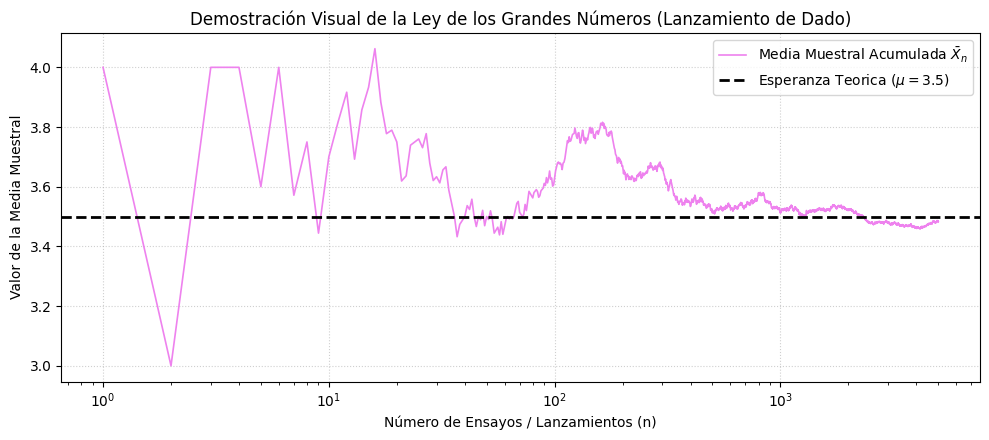

In [57]:
# Demostracion practica de la Ley de los Grandes Numeros simulando tiradas de dados
np.random.seed(101)

n_tiros = 5000
# Simulamos lanzamientos de un dado no justo (valores del 1 al 6)
lanzamientos = np.random.randint(1, 7, size=n_tiros)

# Calculamos las medias acumuladas conforme vamos aumentando el numero de tiros
medias_acumuladas = np.cumsum(lanzamientos) / np.arange(1, n_tiros + 1)

mu_teorica = 3.5 # Esperanza teorica del dado es (1+2+3+4+5+6)/6 = 3.5

plt.figure(figsize=(10, 4.5))
plt.plot(np.arange(1, n_tiros + 1), medias_acumuladas, color='violet', lw=1.2, label='Media Muestral Acumulada $\\bar{X}_n$')
plt.axhline(y=mu_teorica, color='black', linestyle='--', linewidth=2, label='Esperanza Teorica ($\\mu = 3.5$)')
plt.title("Demostración Visual de la Ley de los Grandes Números (Lanzamiento de Dado)", fontsize=12)
plt.xscale('log')
plt.xlabel("Número de Ensayos / Lanzamientos (n)")
plt.ylabel("Valor de la Media Muestral")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

---

## 8. Teorema del Límite Central (TCL)

El **Teorema del Límite Central** (Ross, Cap. 8 / Bertsekas, Cap. 7) es el resultado pilar de la inferencia estadística.

### Enunciado Formal:
Sean $X_1, X_2, \dots, X_n$ variables aleatorias independientes e idénticamente distribuidas (i.i.d.) provenientes de **cualquier** distribución con media $\mu$ y varianza finita $\sigma^2 < \infty$.

A medida que $n \to \infty$, la distribución de la suma estandarizada (o media estandarizada) **converge en distribución** a una Normal estándar $\mathcal{N}(0, 1)$:
$$Z_n = \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} = \frac{\sum_{i=1}^n X_i - n\mu}{\sigma \sqrt{n}} \xrightarrow{d} \mathcal{N}(0, 1)$$

Esto equivale a decir que para todo $z \in \mathbb{R}$:
$$\lim_{n \to \infty} P(Z_n \leq z) = \Phi(z) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^z e^{-\frac{u^2}{2}} du$$

#### Importancia Práctica:
Permite realizar inferencia estadística y construir intervalos de confianza sobre la media poblacional $\mu$ sin necesidad de conocer la distribución original de los datos, siempre que el tamaño de muestra $n$ sea suficientemente grande (típicamente $n \geq 30$).

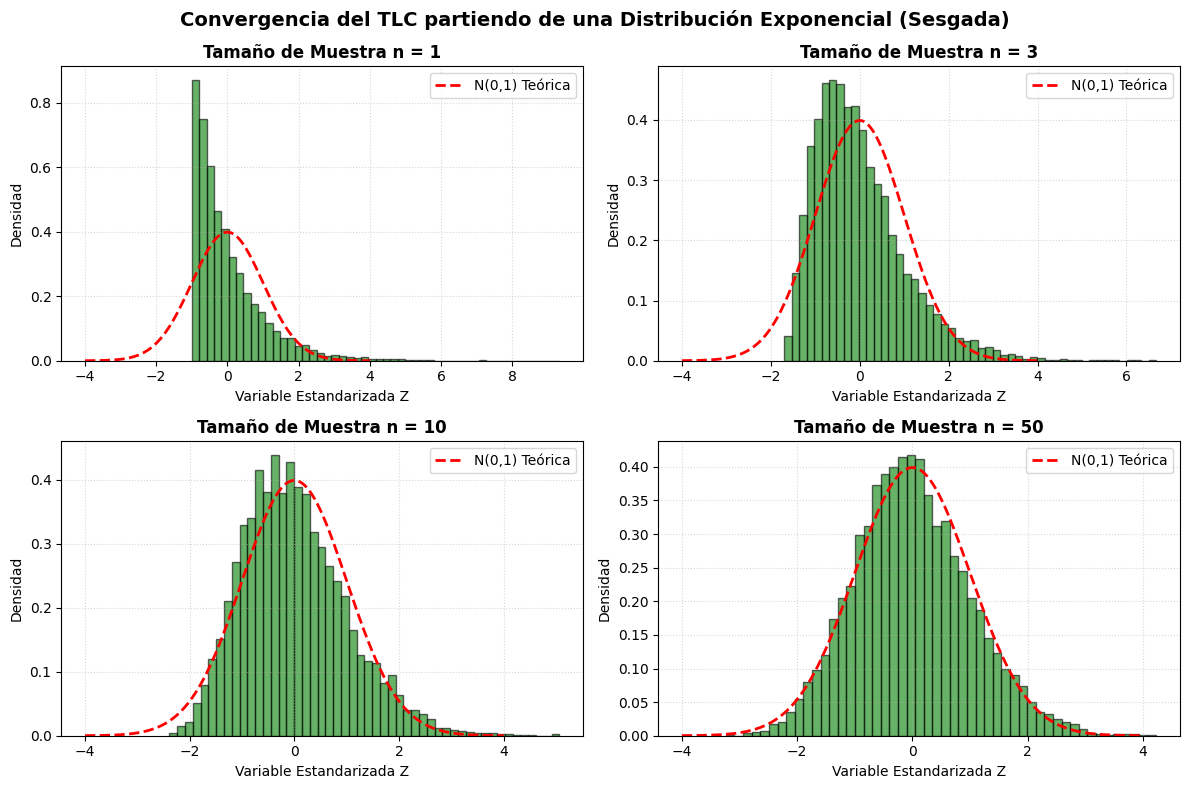

In [58]:
# Verificacion experimental del TLC usando una distribucion fuertemente sesgada (Exponencial)
np.random.seed(2024)

lam_origen = 0.5
mu_origen = 1 / lam_origen # mu = 2.0
sigma_origen = 1 / lam_origen # sigma = 2.0

num_experimentos = 10000 # Cuantas medias vamos a calcular
tamanos_n = [1, 3, 10, 50] # Diferentes tamaños de muestra para ver como emerge la normal, simularemos 4 escenarios

plt.figure(figsize=(12, 8))

for i, n in enumerate(tamanos_n, 1):
    # Generamos directamente una matriz de experimentos para agilizar
    muestras = np.random.exponential(scale=1/lam_origen, size=(num_experimentos, n))
    medias_muestrales = muestras.mean(axis=1)
    
    # Estandarizamos cada media para llevarla a Z
    z_valores = (medias_muestrales - mu_origen) / (sigma_origen / np.sqrt(n))
    
    plt.subplot(2, 2, i)
    plt.hist(z_valores, bins=50, density=True, alpha=0.6, color='green', edgecolor='black')
    
    # Graficamos la curva Normal(0,1) teorica de referencia
    x_z = np.linspace(-4, 4, 300)
    plt.plot(x_z, stats.norm.pdf(x_z), 'r--', lw=2, label='N(0,1) Teórica')
    plt.title(f"Tamaño de Muestra n = {n}", fontweight='bold')
    plt.xlabel("Variable Estandarizada Z")
    plt.ylabel("Densidad")
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.legend()

plt.suptitle("Convergencia del TLC partiendo de una Distribución Exponencial (Sesgada)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()